# Notebook 5 — Correlation Analysis: **Could CO₂ explain the plant–valence link?**

**One question.** The valence ML pipeline (`04_03_ml_pipeline_valence.ipynb`)
shows the plant's bioelectric signal carries *some* predictive information
about **valence**. This notebook asks a single, focused follow-up:

> **Is there supporting evidence that ambient CO₂ — not the plant "feeling"
> anything — is why the plant signal changes when valence changes?**

The worry is a classic **common-cause / confound**. When a participant's
valence shifts, their breathing shifts, which shifts ambient **CO₂**, which
can drift the plant-electrode voltage. If that pathway is real, the plant
would appear to track valence *only because CO₂ drives both*.

We test this as a **triangle**. CO₂ can be the explanation **only if both
legs of the CO₂ pathway hold**:

1. **plant ↔ CO₂** — the plant features co-vary with CO₂, **and**
2. **CO₂ ↔ valence** — CO₂ co-varies with the valence signal itself.

If **either** leg is absent, CO₂ cannot be what makes the plant move with
valence. If **both** hold, CO₂ is a plausible confound and the plant↔valence
result deserves caution. A single figure (§6) reads the verdict off at a glance.

**How we decide.** The triangle (§6) tells us whether CO₂ *could* be a common driver — both its legs must hold. But the decisive question is sharper: **does the plant↔valence association survive once CO₂ is held constant?** § 5 answers it with a **partial Spearman correlation**, `ρ(plant, valence | CO₂)`. If that near-zeroes the plant↔valence link, CO₂ isn't merely a candidate confound — it accounts for the link.

## 1  Configuration & Imports

Everything tunable lives here. Reference columns (CO₂, valence signal) are
*resolved* against the dataset header in §2 — nothing is assumed to exist.

In [33]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import seaborn as sns
from scipy.stats import spearmanr
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from IPython.display import display, Markdown

try:
    from xgboost import XGBClassifier
    XGBOOST_OK = True
except ImportError:
    XGBOOST_OK = False
    print("xgboost not installed - the feature-importance ranking will use Random Forest only.")

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# --- paths -------------------------------------------------------------
DATASET_CSV = Path("../data/datasets/consolidated_dataset.csv")            # output of Notebook 1
OUTPUT_CSV  = Path("../data/datasets/correlation_co2_valence_results.csv")

PLANT_CANDIDATE_FEATURES = [
    "plant_mean", "plant_median", "plant_std", "plant_detrend_std", "plant_iqr",
    "plant_min", "plant_max", "plant_range", "plant_rms", "plant_zcr",
    "bp_0_1", "bp_1_5", "bp_5_15", "bp_15_30", "band_power_sum",
    "ratio_bp1_5_bp5_15", "ratio_bp1_5_total",
    "hjorth_activity", "hjorth_mobility", "hjorth_complexity",
    "spectral_entropy", "spike_rate",
    "plant_sat_pos_frac", "plant_sat_neg_frac",
]

# --- statistics --------------------------------------------------------
ALPHA     = 0.05          # significance threshold for every Spearman test
LAG_RANGE = range(1, 6)   # plant may react to CO2 with a delay: test lags 1-5 windows (30 s each)
N_TOP     = len(PLANT_CANDIDATE_FEATURES)           # number of top valence-predictive plant features to carry through

# --- "leg present" decision rule (used by both the verdict and the figure)
RHO_MIN  = 0.15           # a leg needs at least this mean |rho| to count as present
SIG_FRAC = 0.40           # ...and at least this fraction of its features significant

# --- reference signals, resolved against the header in §2 --------------
TARGET_COL               = "valence_direction"     # the 04_03 target (used only to rank features)
VALENCE_SIGNAL_CANDIDATES = ["fer_valence"]        # the continuous valence signal that target is thresholded from
CO2_CANDIDATES           = ["co2", "co2_ppm", "CO2", "co2_concentration"]

# Plant features = the RAW plant-bioelectric set the valence pipeline (04_03 §3)
# selects from. We rank these by importance for valence and keep the top N_TOP.
# Constant / QA-flag columns are pruned automatically in §3.
PLANT_CANDIDATE_FEATURES = [
    "plant_mean", "plant_median", "plant_std", "plant_detrend_std", "plant_iqr",
    "plant_min", "plant_max", "plant_range", "plant_rms", "plant_zcr",
    "bp_0_1", "bp_1_5", "bp_5_15", "bp_15_30", "band_power_sum",
    "ratio_bp1_5_bp5_15", "ratio_bp1_5_total",
    "hjorth_activity", "hjorth_mobility", "hjorth_complexity",
    "spectral_entropy", "spike_rate",
    "plant_sat_pos_frac", "plant_sat_neg_frac",
]

DROP_DEAD_WINDOWS = True   # exclude electrode-failure windows, exactly as 04_03 §4 does

print(f"Dataset: {DATASET_CSV.resolve()}")
print(f"Output : {OUTPUT_CSV.resolve()}")
print(f"XGBoost available: {XGBOOST_OK}")

Dataset: C:\Uni Koeln\COIN_Project\COIN2026_Team-1_Plant-Emotion-Detector\data\datasets\consolidated_dataset.csv
Output : C:\Uni Koeln\COIN_Project\COIN2026_Team-1_Plant-Emotion-Detector\data\datasets\correlation_co2_valence_results.csv
XGBoost available: True


## 2  Load Data & Resolve Columns

We load the consolidated dataset, resolve the CO₂ and valence-signal columns
against the real header, and (like `04_03` §4) drop dead-electrode windows so
the feature ranking and the correlations use the same clean rows the valence
model was trained on.

In [34]:
df = pd.read_csv(DATASET_CSV)
print(f"Loaded {df.shape[0]} rows x {df.shape[1]} columns "
      f"from {df['session_id'].nunique()} sessions / {df['participant_id'].nunique()} participants")

# Resolve reference columns
CO2_COL            = next((c for c in CO2_CANDIDATES if c in df.columns), None)
VALENCE_SIGNAL_COL = next((c for c in VALENCE_SIGNAL_CANDIDATES if c in df.columns), None)

assert TARGET_COL in df.columns, f"target '{TARGET_COL}' not in dataset - needed to rank features"
assert VALENCE_SIGNAL_COL is not None, (
    "no valence signal (fer_valence) found - the CO2<->valence leg cannot be tested")

# Drop dead-electrode windows (04_03 §4), if the flag is present
if DROP_DEAD_WINDOWS and "plant_dead_flag" in df.columns:
    before = len(df)
    dead = df["plant_dead_flag"].astype(str).str.lower().isin(["true", "1"])
    df = df[~dead].reset_index(drop=True)
    print(f"Dropped {before - len(df)} dead-electrode windows ({len(df)} rows remain).")

resolved = {
    "CO2 column":            CO2_COL if CO2_COL else "NOT FOUND - CO2 legs will be skipped",
    "Valence signal column": VALENCE_SIGNAL_COL,
    "Valence target (for ranking only)": TARGET_COL,
}
display(Markdown("**Columns resolved from the dataset header:**\n\n" +
                 "\n".join(f"- **{k}:** `{v}`" for k, v in resolved.items())))

Loaded 284 rows x 83 columns from 15 sessions / 15 participants
Dropped 0 dead-electrode windows (284 rows remain).


**Columns resolved from the dataset header:**

- **CO2 column:** `co2`
- **Valence signal column:** `fer_valence`
- **Valence target (for ranking only):** `valence_direction`

## 3  Plant Features **from the Valence Pipeline** (all, ranked for context)

The plant signal is many features, so we reduce it to the **10 that matter
most for valence** — using the *same* logic as `04_03_ml_pipeline_valence.ipynb`
§14: train tree models to predict **`valence_direction`** from the raw plant
features and rank by `feature_importances_`. Unlike the previous version of
this notebook, we rank **only against valence** (not the crossed `label` /
`arousal_level` targets). **`N_TOP` is set to the full feature set**, so this
ranking is descriptive only — every plant feature is carried forward, not just a top slice.

Re-running this cell re-derives the ranking from the current data — nothing
is pinned by hand.

In [35]:
# Candidate plant features that are present and actually vary
candidate_feats = [c for c in PLANT_CANDIDATE_FEATURES if c in df.columns]
nunique = df[candidate_feats].nunique()
candidate_feats = [c for c in candidate_feats if nunique[c] > 1]   # drop constant columns

X = df[candidate_feats].apply(pd.to_numeric, errors="coerce")
X = X.fillna(X.median(numeric_only=True))
y = df[TARGET_COL].astype(str)

# Mirror 04_03: RandomForest (+ XGBoost if available), valence target only
importances = []
rf = RandomForestClassifier(n_estimators=300, class_weight="balanced",
                            random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X, y)
importances.append(pd.Series(rf.feature_importances_, index=candidate_feats, name="RF_valence"))

if XGBOOST_OK:
    y_enc = LabelEncoder().fit_transform(y)
    xgb = XGBClassifier(n_estimators=300, random_state=RANDOM_STATE,
                        eval_metric="mlogloss", verbosity=0)
    xgb.fit(X, y_enc)
    importances.append(pd.Series(xgb.feature_importances_, index=candidate_feats, name="XGB_valence"))

importance_df = pd.concat(importances, axis=1)
importance_df["mean_importance"] = importance_df.mean(axis=1)
importance_df = importance_df.sort_values("mean_importance", ascending=False)

TOP_PLANT_FEATURES = importance_df.head(N_TOP).index.tolist()
N_TOP = len(TOP_PLANT_FEATURES)   # actual count carried (constants already dropped above)

display(importance_df.round(3))
display(Markdown(
    f"**All {N_TOP} plant features carried forward** (N_TOP is set to the full set, so the "
    f"ranking above is descriptive only — nothing is dropped). Mean importance over "
    f"{importance_df.shape[1]-1} model(s) on `{TARGET_COL}`:\n\n`{TOP_PLANT_FEATURES}`"))

,RF_valence,XGB_valence,mean_importance
plant_detrend_std,0.036,0.105,0.071
plant_max,0.062,0.057,0.059
hjorth_mobility,0.050,0.064,0.057
plant_range,0.055,0.051,0.053
ratio_bp1_5_total,0.055,0.049,0.052
plant_min,0.061,0.041,0.051
ratio_bp1_5_bp5_15,0.054,0.045,0.049
plant_iqr,0.043,0.055,0.049
plant_mean,0.043,0.052,0.048
hjorth_complexity,0.046,0.049,0.048


**All 22 plant features carried forward** (N_TOP is set to the full set, so the ranking above is descriptive only — nothing is dropped). Mean importance over 2 model(s) on `valence_direction`:

`['plant_detrend_std', 'plant_max', 'hjorth_mobility', 'plant_range', 'ratio_bp1_5_total', 'plant_min', 'ratio_bp1_5_bp5_15', 'plant_iqr', 'plant_mean', 'hjorth_complexity', 'bp_0_1', 'plant_std', 'plant_median', 'spectral_entropy', 'plant_zcr', 'bp_5_15', 'spike_rate', 'band_power_sum', 'bp_1_5', 'bp_15_30', 'plant_rms', 'hjorth_activity']`

## 4  The Question as a Testable Triangle

Three nodes — **VALENCE**, **CO₂**, **PLANT SIGNAL** — and three edges:

| Edge | What it is | Role |
|---|---|---|
| **plant ↔ valence** | all plant features vs `fer_valence` | the effect we are trying to *explain* |
| **plant ↔ CO₂** | all plant features vs CO₂ | **leg 1** of the candidate CO₂ pathway |
| **CO₂ ↔ valence** | CO₂ vs `fer_valence` | **leg 2** of the candidate CO₂ pathway |

**Decision rule.** CO₂ is a *plausible* reason the plant tracks valence only
if **both** CO₂ legs are present. We call a leg **present** when its mean
`|ρ| ≥ RHO_MIN` *and* at least `SIG_FRAC` of its features are significant
(for the single CO₂↔valence test: `p < ALPHA` and `|ρ| ≥ RHO_MIN`).

- both legs present → **PLAUSIBLE** (CO₂ is a viable common driver — caution)
- one leg present → **PARTIAL** (CO₂ alone cannot be the explanation)
- neither → **NOT SUPPORTED** (the CO₂ story is broken)

**Method.** Every edge is a **Spearman ρ** (rank-based, no normality
assumption, outlier-robust). Rolling/lag operations are done **per session**
(`groupby("session_id")`) so windows are never compared across recordings.
For **plant ↔ CO₂** we also scan lags 1–5 (CO₂ shifted forward within each
session) and report the strongest, since a plant drifting in response to
accumulating CO₂ would react with a delay. Correlating *signals* (not model
outputs) keeps this non-circular: CO₂ and `fer_valence` are measured
independently of the plant.

## 5  Compute the Legs — and the Decisive Partial Correlation

One Spearman helper per edge, as before. Then the key addition: for each
plant feature we compute the **partial Spearman**
`ρ(plant, valence | CO₂)` — the plant↔valence rank association with CO₂
statistically removed (first-order partial correlation on the pooled raw
per-window values, matching the *raw* variant's pooling).

- If the **partial** correlations stay close to the raw plant↔valence
  correlations → CO₂ does **not** explain the link.
- If they **collapse toward zero** → the plant only appeared to track valence
  because both ride on CO₂. That is the confound, made quantitative.

We also report a back-of-envelope indirect-effect estimate (the product of
the two CO₂ legs) as a sanity check on the partial-correlation result.

In [36]:
def _spear(x, y):
    """Spearman rho, p, n on the overlapping non-NaN rows of two series."""
    m = x.notna() & y.notna()
    if m.sum() < 3:
        return np.nan, np.nan, int(m.sum())
    rho, p = spearmanr(x[m], y[m])
    return rho, p, int(m.sum())


def _best_lag(data, ref_col, feat, lags):
    """Strongest |rho| between ref_col (shifted forward per session) and feat."""
    r0, p0, n0 = _spear(data[ref_col], data[feat])
    best = dict(lag=0, rho=r0, p=p0, n=n0)
    for lag in lags:
        shifted = data.groupby("session_id")[ref_col].transform(lambda s: s.shift(lag))
        rho, p, n = _spear(shifted, data[feat])
        if not np.isnan(rho) and (np.isnan(best["rho"]) or abs(rho) > abs(best["rho"])):
            best = dict(lag=lag, rho=rho, p=p, n=n)
    return best


def _per_feature_leg(ref_col, name, with_lag=False):
    rows = []
    for f in TOP_PLANT_FEATURES:
        rho, p, n = _spear(df[ref_col], df[f])
        row = dict(leg=name, plant_feature=f, rho=rho, p_value=p, n=n,
                   best_lag=np.nan, best_lag_rho=np.nan, best_lag_p=np.nan)
        if with_lag:
            bl = _best_lag(df, ref_col, f, LAG_RANGE)
            row.update(best_lag=bl["lag"], best_lag_rho=bl["rho"], best_lag_p=bl["p"])
        rows.append(row)
    return pd.DataFrame(rows)


def _leg_present(mean_abs_rho, sig_frac):
    return (mean_abs_rho >= RHO_MIN) and (sig_frac >= SIG_FRAC)


# --- Leg: plant <-> valence (the effect to explain) --------------------
leg_plant_val = _per_feature_leg(VALENCE_SIGNAL_COL, "plant<->valence")

# --- CO2 legs (only if CO2 is present) ---------------------------------
if CO2_COL is not None:
    leg_plant_co2 = _per_feature_leg(CO2_COL, "plant<->CO2", with_lag=True)
    co2_val_rho, co2_val_p, co2_val_n = _spear(df[CO2_COL], df[VALENCE_SIGNAL_COL])
else:
    leg_plant_co2 = pd.DataFrame(columns=leg_plant_val.columns)
    co2_val_rho, co2_val_p, co2_val_n = np.nan, np.nan, 0

# --- summarise each leg ------------------------------------------------
def _summ(dfleg, rho_col="rho", p_col="p_value"):
    if dfleg.empty:
        return 0.0, 0, 0.0
    mean_abs = dfleg[rho_col].abs().mean()
    n_sig = int((dfleg[p_col] < ALPHA).sum())
    return mean_abs, n_sig, n_sig / len(dfleg)

PV_mean, PV_sig, PV_frac = _summ(leg_plant_val)
# for plant<->CO2 use the lag-optimised rho (best evidence for a delayed drift)
PC_mean, PC_sig, PC_frac = (_summ(leg_plant_co2, "best_lag_rho", "best_lag_p")
                            if not leg_plant_co2.empty else (0.0, 0, 0.0))

legPC_present = _leg_present(PC_mean, PC_frac)
legCV_present = (not np.isnan(co2_val_p)) and (co2_val_p < ALPHA) and (abs(co2_val_rho) >= RHO_MIN)

if CO2_COL is None:
    verdict = "NO CO2 DATA"
elif legPC_present and legCV_present:
    verdict = "PLAUSIBLE"
elif legPC_present or legCV_present:
    verdict = "PARTIAL"
else:
    verdict = "NOT SUPPORTED"

# --- tidy table + CSV --------------------------------------------------
legs = pd.concat([leg_plant_val, leg_plant_co2], ignore_index=True)
legs["significant"] = legs["p_value"] < ALPHA
legs.to_csv(OUTPUT_CSV, index=False)

print(f"Leg summaries (mean |rho| over all {N_TOP} features, # significant):")
print(f"  plant <-> valence   : mean|rho|={PV_mean:.3f}   {PV_sig}/{N_TOP} sig   "
      f"[the effect to explain]")
print(f"  plant <-> CO2 (lag)  : mean|rho|={PC_mean:.3f}   {PC_sig}/{N_TOP} sig   "
      f"present={legPC_present}")
print(f"  CO2   <-> valence    : rho={co2_val_rho:.3f}  p={co2_val_p:.4f}  n={co2_val_n}   "
      f"present={legCV_present}")
print(f"\n==> CO2-as-driver verdict: {verdict}")
print(f"Saved {len(legs)} rows to {OUTPUT_CSV.resolve()}")


# ── Decisive test: partial Spearman  rho(plant, valence | CO2) ──────────
from scipy.stats import t as _tdist

def _partial_spearman(x, y, z):
    """First-order partial Spearman of (x, y) controlling for z, on the
    pooled non-NaN rows (matches the 'raw' variant's pooling). Returns
    (partial_rho, p_value, n)."""
    m = x.notna() & y.notna() & z.notna()
    n = int(m.sum())
    if n < 5:
        return np.nan, np.nan, n
    r_xy = spearmanr(x[m], y[m]).correlation
    r_xz = spearmanr(x[m], z[m]).correlation
    r_yz = spearmanr(y[m], z[m]).correlation
    denom = np.sqrt((1 - r_xz**2) * (1 - r_yz**2))
    if not np.isfinite(denom) or denom == 0:
        return np.nan, np.nan, n
    r = (r_xy - r_xz * r_yz) / denom
    dfree = n - 3                      # 2 fewer than usual: one covariate controlled
    if dfree <= 0 or abs(r) >= 1:
        return r, np.nan, n
    tstat = r * np.sqrt(dfree / (1 - r**2))
    p = 2 * _tdist.sf(abs(tstat), dfree)
    return r, p, n


if CO2_COL is not None:
    partial_rows = []
    for f in TOP_PLANT_FEATURES:
        pr, pp, pn = _partial_spearman(df[f], df[VALENCE_SIGNAL_COL], df[CO2_COL])
        partial_rows.append(dict(plant_feature=f, partial_rho=pr, partial_p=pp, partial_n=pn))
    partial_pv = pd.DataFrame(partial_rows)

    PART_mean = partial_pv["partial_rho"].abs().mean()
    PART_sig  = int((partial_pv["partial_p"] < ALPHA).sum())
    retained  = (PART_mean / PV_mean) if PV_mean > 0 else np.nan   # fraction of the link left after CO2

    # lag-0 plant<->CO2 (honest, un-selected) + product-rule indirect estimate
    PC_mean_lag0 = leg_plant_co2["rho"].abs().mean()
    indirect_est = abs(co2_val_rho) * PC_mean_lag0

    if   retained < 0.5:  confound_verdict = "CONFOUNDED"          # CO2 removes most of the link
    elif retained < 0.8:  confound_verdict = "PARTLY CONFOUNDED"
    else:                 confound_verdict = "SURVIVES CO2 CONTROL"

    # attach partial results to the exported table
    leg_plant_val = leg_plant_val.merge(partial_pv, on="plant_feature", how="left")
    legs = pd.concat([leg_plant_val, leg_plant_co2], ignore_index=True)
    legs["significant"] = legs["p_value"] < ALPHA
    legs.to_csv(OUTPUT_CSV, index=False)

    print("\n--- Decisive test: does plant<->valence survive removing CO2? ---")
    print(f"  plant <-> valence  (raw)        : mean|rho|={PV_mean:.3f}   {PV_sig}/{N_TOP} sig")
    print(f"  plant <-> valence  (| CO2)      : mean|rho|={PART_mean:.3f}   {PART_sig}/{N_TOP} sig   "
          f"-> {100*(1-retained):.0f}% of the association removed by controlling for CO2")
    print(f"  indirect estimate (CO2 product) : |{co2_val_rho:.3f}| x {PC_mean_lag0:.3f} = {indirect_est:.3f}   "
          f"(cf. raw plant<->valence {PV_mean:.3f})")
    print(f"\n==> Confound verdict: {confound_verdict}")
else:
    partial_pv = pd.DataFrame(columns=["plant_feature", "partial_rho", "partial_p", "partial_n"])
    PART_mean, PART_sig, retained = np.nan, 0, np.nan
    PC_mean_lag0, indirect_est = np.nan, np.nan
    confound_verdict = "NO CO2 DATA"

Leg summaries (mean |rho| over all 22 features, # significant):
  plant <-> valence   : mean|rho|=0.140   13/22 sig   [the effect to explain]
  plant <-> CO2 (lag)  : mean|rho|=0.420   18/22 sig   present=True
  CO2   <-> valence    : rho=0.308  p=0.0000  n=284   present=True

==> CO2-as-driver verdict: PLAUSIBLE
Saved 44 rows to C:\Uni Koeln\COIN_Project\COIN2026_Team-1_Plant-Emotion-Detector\data\datasets\correlation_co2_valence_results.csv

--- Decisive test: does plant<->valence survive removing CO2? ---
  plant <-> valence  (raw)        : mean|rho|=0.140   13/22 sig
  plant <-> valence  (| CO2)      : mean|rho|=0.145   13/22 sig   -> -3% of the association removed by controlling for CO2
  indirect estimate (CO2 product) : |0.308| x 0.405 = 0.125   (cf. raw plant<->valence 0.140)

==> Confound verdict: SURVIVES CO2 CONTROL


### Interpreting the three legs — and the decisive test

**The question: does CO₂ have anything to do with what the plant senses?** The answer splits in two, and the halves point different ways — which is fine, because they are two different questions. (Exact figures for this run are in §5 above, summarised in §7, and compared raw-vs-within-session in §9.)

**(1) CO₂ ↔ the plant signal.** Read the `plant ↔ CO₂` leg. If it is the strongest edge, the plant's features clearly co-vary with ambient CO₂ — expected from `02_emotion_labelling.ipynb` §4.10, where CO₂ is named as one driver of the plant's slow voltage-baseline drift. So CO₂ **is** part of what the plant electrode picks up.

**(2) CO₂ ↔ the plant's *valence* signal.** This is the decisive test — the partial correlation. "Controlling for CO₂" means stripping CO₂'s footprint out of *both* the plant features and valence, then correlating the leftovers. If CO₂ were the glue holding them together, the leftovers would come apart and the correlation would fall toward zero; whether it does is the **confound verdict** in §5 and the plant↔valence edge label in the figure.

**Why the two legs can look large yet nothing cancels.** The product of the two legs is a magnitude-only heuristic that ignores sign. The partial correlation keeps sign per feature: if the plant↔valence signs run opposite to the CO₂ pathway, CO₂ is *masking* the link rather than creating it, so removing it leaves the association intact.

**⚠️ Between-session CO₂.** These raw ρ's pool across all sessions, so the `plant ↔ CO₂` value mixes within-session co-movement with between-session offsets (stuffier rooms, open doors/windows). §8 repeats the whole analysis *within* session to separate the two — see §9 for the side-by-side.

## 6  Verdict Figure

**Left — the triangle.** Solid blue = a real link, dashed grey = weak /
non-significant. The plant↔valence edge now shows **both** its raw strength
and its strength *after controlling for CO₂* (`raw → | CO₂`), so the collapse
(or survival) is visible on the edge itself.

**Right — the decisive per-feature view.** For each feature, its
plant↔valence association **before** (purple) and **after** (vermillion)
removing CO₂, joined by a line. Dots sliding left toward the dotted
`RHO_MIN` line mean CO₂ is doing the work; dots that stay put mean the plant
tracks valence independently of CO₂.

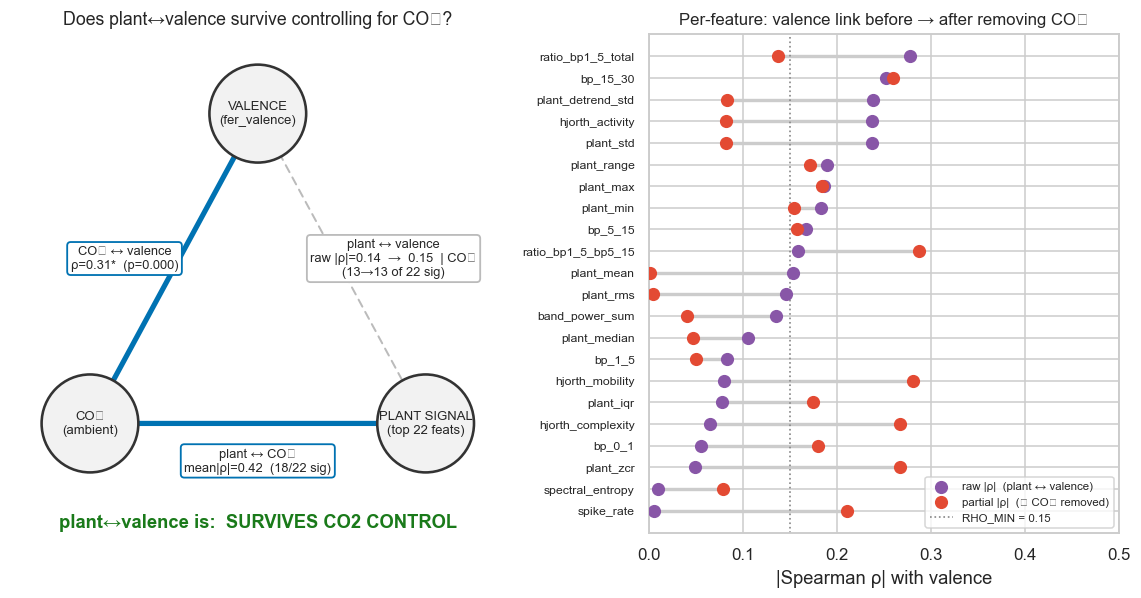

In [37]:
if CO2_COL is None:
    print("CO2 column not found - cannot draw the CO2 triangle.")
else:
    def _es(present):
        return ("#0072B2" if present else "#BBBBBB",
                3.4 if present else 1.3,
                "solid" if present else (0, (4, 3)))

    fig = plt.figure(figsize=(13, 5.9))
    gs = fig.add_gridspec(1, 2, width_ratios=[1.05, 1.0], wspace=0.30)
    ax1, ax2 = fig.add_subplot(gs[0]), fig.add_subplot(gs[1])

    # ---- triangle ----------------------------------------------------
    ax1.set_xlim(0, 10); ax1.set_ylim(0, 10); ax1.axis("off")
    P = {"VAL": (5.0, 8.4), "CO2": (1.6, 2.2), "PLANT": (8.4, 2.2)}
    node_txt = {"VAL": "VALENCE\n(fer_valence)", "CO2": "CO\u2082\n(ambient)",
                "PLANT": f"PLANT SIGNAL\n(top {N_TOP} feats)"}

    def draw_edge(a, b, present, label, lx, ly):
        color, lw, ls = _es(present)
        (x1, y1), (x2, y2) = P[a], P[b]
        ax1.annotate("", xy=(x2, y2), xytext=(x1, y1),
                     arrowprops=dict(arrowstyle="-", color=color, lw=lw, linestyle=ls))
        ax1.text(lx, ly, label, ha="center", va="center", fontsize=8.4,
                 bbox=dict(boxstyle="round,pad=0.28", fc="white", ec=color, lw=1.2))

    draw_edge("VAL", "PLANT", _leg_present(PV_mean, PV_frac),
              f"plant \u2194 valence\nraw |\u03c1|={PV_mean:.2f}  \u2192  {PART_mean:.2f}  | CO\u2082\n"
              f"({PV_sig}\u2192{PART_sig} of {N_TOP} sig)", 7.75, 5.5)
    draw_edge("CO2", "PLANT", legPC_present,
              f"plant \u2194 CO\u2082\nmean|\u03c1|={PC_mean:.2f}  ({PC_sig}/{N_TOP} sig)", 5.0, 1.45)
    star = "*" if legCV_present else ""
    draw_edge("CO2", "VAL", legCV_present,
              f"CO\u2082 \u2194 valence\n\u03c1={co2_val_rho:.2f}{star}  (p={co2_val_p:.3f})", 2.3, 5.5)

    for k, (x, y) in P.items():
        ax1.add_patch(Circle((x, y), 0.98, fc="#F2F2F2", ec="#333333", lw=1.7, zorder=5))
        ax1.text(x, y, node_txt[k], ha="center", va="center", fontsize=8.6, zorder=6)

    vcolor = {"CONFOUNDED": "#B00020", "PARTLY CONFOUNDED": "#B8860B",
              "SURVIVES CO2 CONTROL": "#1a7a1a", "NO CO2 DATA": "#555555"}[confound_verdict]
    ax1.text(5, 0.12, f"plant\u2194valence is:  {confound_verdict}", ha="center",
             fontsize=12, color=vcolor, weight="bold")
    ax1.set_title("Does plant\u2194valence survive controlling for CO\u2082?", fontsize=11.5)

    # ---- per-feature before/after dumbbell ---------------------------
    m = leg_plant_val.copy()   # already carries rho and partial_rho from the legs cell
    m = m.reindex(m["rho"].abs().sort_values().index).reset_index(drop=True)
    yy = np.arange(len(m))
    for i, r in m.iterrows():
        ax2.plot([abs(r["rho"]), abs(r["partial_rho"])], [i, i], color="#CCCCCC", lw=2.2, zorder=1)
    ax2.scatter(m["rho"].abs(), yy, s=58, color="#8856a7", zorder=3,
                label="raw |\u03c1|  (plant \u2194 valence)")
    ax2.scatter(m["partial_rho"].abs(), yy, s=58, color="#e34a33", zorder=3,
                label="partial |\u03c1|  (\u2223 CO\u2082 removed)")
    ax2.axvline(RHO_MIN, color="#888888", ls=":", lw=1.1, label=f"RHO_MIN = {RHO_MIN}")
    ax2.set_yticks(yy); ax2.set_yticklabels(m["plant_feature"], fontsize=8)
    ax2.set_xlabel("|Spearman \u03c1| with valence")
    ax2.set_xlim(0, max(0.5, m["rho"].abs().max() * 1.15))
    ax2.set_title("Per-feature: valence link before \u2192 after removing CO\u2082", fontsize=11)
    ax2.legend(fontsize=7.5, loc="lower right")

    plt.tight_layout()
    plt.show()

### Reconciling the two verdicts

The figure shows two verdicts that can look like they disagree — they don't:

- **Triangle verdict = PLAUSIBLE.** This only checks that the *preconditions* for a CO₂ confound exist: both CO₂ legs (`plant↔CO₂` and `CO₂↔valence`) are real. It is a screening test and is prone to false positives.
- **Confound verdict = SURVIVES CO₂ CONTROL.** This is the partial correlation — whether the confounding *actually happens*. Here it says **no**: removing CO₂ does not shrink the plant↔valence link.

They answer different questions, so both can be true at once: the preconditions are met (hence PLAUSIBLE), but the plant↔valence relationship does not actually run through CO₂ (hence SURVIVES). **Trust the partial correlation** — it is the decisive test; the triangle is only the screen.

## 7  Interpretation

In [38]:
if CO2_COL is None:
    display(Markdown("CO\u2082 was not found in the dataset, so the confound question cannot be tested here."))
else:
    n_sessions = df["session_id"].nunique()

    # Direction of the partial-correlation change. (Fixes the earlier "-8% removed"
    # wording: a NEGATIVE "removed" just means the association did not shrink.)
    delta = PART_mean - PV_mean
    pct   = 100 * delta / PV_mean if PV_mean > 0 else float("nan")
    if abs(pct) < 5:
        change_phrase = f"essentially unchanged (mean|\u03c1| {PV_mean:.2f} \u2192 {PART_mean:.2f})"
    elif delta < 0:
        change_phrase = f"reduced by ~{abs(pct):.0f}% (mean|\u03c1| {PV_mean:.2f} \u2192 {PART_mean:.2f})"
    else:
        change_phrase = f"slightly stronger rather than weaker (mean|\u03c1| {PV_mean:.2f} \u2192 {PART_mean:.2f})"

    if confound_verdict == "CONFOUNDED":
        headline = (f"**CO\u2082 accounts for most of the plant\u2194valence link.** With CO\u2082 held constant "
                    f"the association is {change_phrase}.")
    elif confound_verdict == "PARTLY CONFOUNDED":
        headline = (f"**CO\u2082 accounts for part of the plant\u2194valence link.** With CO\u2082 held constant "
                    f"it is {change_phrase}; a residual remains.")
    else:
        headline = (f"**The plant\u2194valence link is not explained by CO\u2082.** With CO\u2082 held constant "
                    f"it is {change_phrase} \u2014 so CO\u2082 is not what drives it.")

    explains = {"CONFOUNDED": "Yes.", "PARTLY CONFOUNDED": "Partly.",
                "SURVIVES CO2 CONTROL": "No."}[confound_verdict]

    lines = [headline, "",
        f"- **Does CO\u2082 relate to the plant signal at all?** "
        + (f"Yes, strongly \u2014 plant\u2194CO\u2082 = {PC_mean:.2f} ({PC_sig}/{N_TOP} significant), the "
           f"strongest edge in the triangle." if legPC_present else
           f"Weakly \u2014 plant\u2194CO\u2082 = {PC_mean:.2f} ({PC_sig}/{N_TOP} significant)."),
        f"- **Does CO\u2082 relate to valence?** "
        + (f"Yes \u2014 CO\u2082\u2194valence = {co2_val_rho:.2f} (p = {co2_val_p:.3f})." if legCV_present else
           f"Not significantly \u2014 CO\u2082\u2194valence = {co2_val_rho:.2f} (p = {co2_val_p:.3f})."),
        f"- **Does CO\u2082 *explain* the plant\u2194valence link?** {explains} "
        f"Controlling for CO\u2082 leaves it {change_phrase}.",
        "",
        f"**Triangle vs partial.** The triangle verdict (**{verdict}**) only checks that the "
        f"*preconditions* for a CO\u2082 confound exist (both legs present); the partial correlation "
        f"(**{confound_verdict}**) checks whether the confounding *actually happens*. Trust the "
        f"partial \u2014 it is the decisive test.",
        "",
        f"**\u26a0\ufe0f Between-session caveat.** These \u03c1's pool all {co2_val_n} windows across "
        f"{n_sessions} sessions. Ambient CO\u2082 varies widely between sessions (doors, windows, "
        f"occupancy), so part of plant\u2194CO\u2082 = {PC_mean:.2f} may be between-session offset rather "
        f"than within-session sensing \u2014 a within-session test (session-mean-centre both signals, "
        f"or per-session \u03c1) would isolate genuine sensing. Treat {PC_mean:.2f} as an upper bound.",
        "",
        "_Other caveats._ Partialling removes CO\u2082 only as a **monotonic** driver; correlations are "
        "pooled (not per-session); plant\u2194CO\u2082 uses the best of lags 0\u20135 (upper estimate \u2014 the "
        "partial test uses lag-0); pilot cohort, so wide confidence intervals; and `02` \u00a74.10 notes "
        "the plant channel's physiological validity is itself unresolved (~50 Hz mains dominates raw "
        "power).",
    ]
    display(Markdown("\n".join(lines)))

**The plant↔valence link is not explained by CO₂.** With CO₂ held constant it is essentially unchanged (mean|ρ| 0.14 → 0.15) — so CO₂ is not what drives it.

- **Does CO₂ relate to the plant signal at all?** Yes, strongly — plant↔CO₂ = 0.42 (18/22 significant), the strongest edge in the triangle.
- **Does CO₂ relate to valence?** Yes — CO₂↔valence = 0.31 (p = 0.000).
- **Does CO₂ *explain* the plant↔valence link?** No. Controlling for CO₂ leaves it essentially unchanged (mean|ρ| 0.14 → 0.15).

**Triangle vs partial.** The triangle verdict (**PLAUSIBLE**) only checks that the *preconditions* for a CO₂ confound exist (both legs present); the partial correlation (**SURVIVES CO2 CONTROL**) checks whether the confounding *actually happens*. Trust the partial — it is the decisive test.

**⚠️ Between-session caveat.** These ρ's pool all 284 windows across 15 sessions. Ambient CO₂ varies widely between sessions (doors, windows, occupancy), so part of plant↔CO₂ = 0.42 may be between-session offset rather than within-session sensing — a within-session test (session-mean-centre both signals, or per-session ρ) would isolate genuine sensing. Treat 0.42 as an upper bound.

_Other caveats._ Partialling removes CO₂ only as a **monotonic** driver; correlations are pooled (not per-session); plant↔CO₂ uses the best of lags 0–5 (upper estimate — the partial test uses lag-0); pilot cohort, so wide confidence intervals; and `02` §4.10 notes the plant channel's physiological validity is itself unresolved (~50 Hz mains dominates raw power).

## 8  Second analysis — session-normalized (`*_snorm`) features (within-session view)

The analysis above uses **raw** plant features, so its correlations mix two
things: co-movement *within* a recording, and offsets *between* sessions
(a stuffier room that also happened to sit at a different electrode
baseline). That between-session part is exactly the open-door/window issue —
and it can inflate the `plant ↔ CO₂` leg without any real sensing.

This section repeats everything on the **session-normalized** plant features
(`*_snorm`, the same robust per-session z-scores `02_emotion_labelling.ipynb`
§4.10b exports and that `04_03` evaluates as a candidate representation). To
keep the comparison clean, **CO₂ and valence are session-normalized the same
way** (per-session median/MAD z-score, computed here as `co2_snorm` /
`fer_valence_snorm`). With every signal centred per session, all
between-session differences are removed, so this is a **purely within-session
test**: *when CO₂ moves inside a single recording, does the plant move — and
does any within-session plant↔valence link survive removing CO₂?*

Reading the two analyses together is the point: **raw = within + between**,
**snorm = within only**. If `plant ↔ CO₂` shrinks a lot from raw to snorm,
much of the raw coupling was just between-session ambient differences.

In [39]:
# --- session-normalize CO2 and valence the same way the plant *_snorm features are built
#     (02 §4.10b: per-session robust z-score, median/MAD) so all signals are session-relative
def _session_robust_z(series, groups):
    def _rz(s):
        med = s.median()
        mad = (s - med).abs().median()
        denom = 1.4826 * mad
        if denom == 0 or np.isnan(denom):
            sd = s.std()
            denom = sd if (sd and not np.isnan(sd)) else np.nan
        return (s - med) / denom if (denom and not np.isnan(denom)) else s * 0.0
    return series.groupby(groups).transform(_rz)

if CO2_COL is not None:
    df["co2_snorm"] = _session_robust_z(df[CO2_COL], df["session_id"])
df["fer_valence_snorm"] = _session_robust_z(df[VALENCE_SIGNAL_COL], df["session_id"])

# --- rank / carry all *_snorm plant features for valence (mirror of section 3) ---
_base_cont = ["plant_mean", "plant_median", "plant_std", "plant_detrend_std", "plant_iqr",
              "plant_min", "plant_max", "plant_range", "plant_rms", "plant_zcr", "bp_0_1",
              "bp_1_5", "bp_5_15", "bp_15_30", "band_power_sum", "ratio_bp1_5_bp5_15",
              "ratio_bp1_5_total", "hjorth_activity", "hjorth_mobility", "hjorth_complexity",
              "spectral_entropy", "spike_rate"]
SN_CANDIDATES = [c + "_snorm" for c in _base_cont if (c + "_snorm") in df.columns]
_nun = df[SN_CANDIDATES].nunique()
SN_CANDIDATES = [c for c in SN_CANDIDATES if _nun[c] > 1]

X_sn = df[SN_CANDIDATES].apply(pd.to_numeric, errors="coerce")
X_sn = X_sn.fillna(X_sn.median(numeric_only=True))
y_sn = df[TARGET_COL].astype(str)

_imp = [pd.Series(RandomForestClassifier(n_estimators=300, class_weight="balanced",
                                         random_state=RANDOM_STATE, n_jobs=-1)
                  .fit(X_sn, y_sn).feature_importances_, index=SN_CANDIDATES, name="RF")]
if XGBOOST_OK:
    _ye = LabelEncoder().fit_transform(y_sn)
    _imp.append(pd.Series(XGBClassifier(n_estimators=300, random_state=RANDOM_STATE,
                                        eval_metric="mlogloss", verbosity=0)
                          .fit(X_sn, _ye).feature_importances_, index=SN_CANDIDATES, name="XGB"))
_imp_sn = pd.concat(_imp, axis=1)
_imp_sn["mean_importance"] = _imp_sn.mean(axis=1)
TOP_SN = _imp_sn.sort_values("mean_importance", ascending=False).head(N_TOP).index.tolist()
N_TOP = len(TOP_SN)   # actual snorm count carried

# --- three legs + partial, all on session-normalized signals ---
def _leg_sn(ref_col, with_lag=False):
    rows = []
    for f in TOP_SN:
        r, p, n = _spear(df[ref_col], df[f])
        row = dict(plant_feature=f, rho=r, p_value=p, n=n,
                   best_lag=np.nan, best_lag_rho=np.nan, best_lag_p=np.nan)
        if with_lag:
            bl = _best_lag(df, ref_col, f, LAG_RANGE)
            row.update(best_lag=bl["lag"], best_lag_rho=bl["rho"], best_lag_p=bl["p"])
        rows.append(row)
    return pd.DataFrame(rows)

if CO2_COL is not None:
    leg_pv_sn = _leg_sn("fer_valence_snorm")
    leg_pc_sn = _leg_sn("co2_snorm", with_lag=True)
    co2v_rho_sn, co2v_p_sn, co2v_n_sn = _spear(df["co2_snorm"], df["fer_valence_snorm"])
    _par = [dict(plant_feature=f,
                 partial_rho=_partial_spearman(df[f], df["fer_valence_snorm"], df["co2_snorm"])[0],
                 partial_p=_partial_spearman(df[f], df["fer_valence_snorm"], df["co2_snorm"])[1])
            for f in TOP_SN]
    leg_pv_sn = leg_pv_sn.merge(pd.DataFrame(_par), on="plant_feature", how="left")

    PV_mean_sn = leg_pv_sn["rho"].abs().mean();          PV_sig_sn = int((leg_pv_sn["p_value"] < ALPHA).sum())
    PART_mean_sn = leg_pv_sn["partial_rho"].abs().mean(); PART_sig_sn = int((leg_pv_sn["partial_p"] < ALPHA).sum())
    PC_mean_sn = leg_pc_sn["best_lag_rho"].abs().mean();  PC_sig_sn = int((leg_pc_sn["best_lag_p"] < ALPHA).sum())
    PC_mean_lag0_sn = leg_pc_sn["rho"].abs().mean()
    PV_frac_sn = PV_sig_sn / N_TOP
    retained_sn = (PART_mean_sn / PV_mean_sn) if PV_mean_sn > 0 else np.nan
    indirect_sn = abs(co2v_rho_sn) * PC_mean_lag0_sn

    legPC_present_sn = _leg_present(PC_mean_sn, PC_sig_sn / N_TOP)
    legCV_present_sn = (not np.isnan(co2v_p_sn)) and (co2v_p_sn < ALPHA) and (abs(co2v_rho_sn) >= RHO_MIN)
    verdict_sn = ("PLAUSIBLE" if (legPC_present_sn and legCV_present_sn) else
                  "PARTIAL" if (legPC_present_sn or legCV_present_sn) else "NOT SUPPORTED")
    confound_verdict_sn = ("CONFOUNDED" if retained_sn < 0.5 else
                           "PARTLY CONFOUNDED" if retained_sn < 0.8 else "SURVIVES CO2 CONTROL")

    print(f"All {N_TOP} session-normalized valence-predictive features:")
    print("  " + ", ".join(TOP_SN))
    print("\nWithin-session (session-normalized) leg summaries:")
    print(f"  plant <-> valence         : mean|rho|={PV_mean_sn:.3f}   {PV_sig_sn}/{N_TOP} sig")
    print(f"  plant <-> valence (| CO2)  : mean|rho|={PART_mean_sn:.3f}   {PART_sig_sn}/{N_TOP} sig   "
          f"-> {100*(1-retained_sn):.0f}% of the association removed by CO2")
    print(f"  plant <-> CO2 (lag)       : mean|rho|={PC_mean_sn:.3f}   {PC_sig_sn}/{N_TOP} sig   present={legPC_present_sn}")
    print(f"  CO2   <-> valence         : rho={co2v_rho_sn:.3f}  p={co2v_p_sn:.4f}  n={co2v_n_sn}   present={legCV_present_sn}")
    print(f"\n  Triangle verdict : {verdict_sn}")
    print(f"  Confound verdict : {confound_verdict_sn}")
else:
    print("CO2 column not found - session-normalized CO2 analysis skipped.")

All 22 session-normalized valence-predictive features:
  plant_min_snorm, hjorth_mobility_snorm, plant_range_snorm, hjorth_complexity_snorm, ratio_bp1_5_bp5_15_snorm, band_power_sum_snorm, plant_zcr_snorm, bp_15_30_snorm, ratio_bp1_5_total_snorm, plant_iqr_snorm, plant_median_snorm, plant_std_snorm, spectral_entropy_snorm, spike_rate_snorm, plant_max_snorm, bp_1_5_snorm, bp_0_1_snorm, plant_rms_snorm, bp_5_15_snorm, plant_mean_snorm, plant_detrend_std_snorm, hjorth_activity_snorm

Within-session (session-normalized) leg summaries:
  plant <-> valence         : mean|rho|=0.075   5/22 sig
  plant <-> valence (| CO2)  : mean|rho|=0.074   6/22 sig   -> 1% of the association removed by CO2
  plant <-> CO2 (lag)       : mean|rho|=0.101   4/22 sig   present=False
  CO2   <-> valence         : rho=0.329  p=0.0000  n=284   present=True

  Triangle verdict : PARTIAL
  Confound verdict : SURVIVES CO2 CONTROL


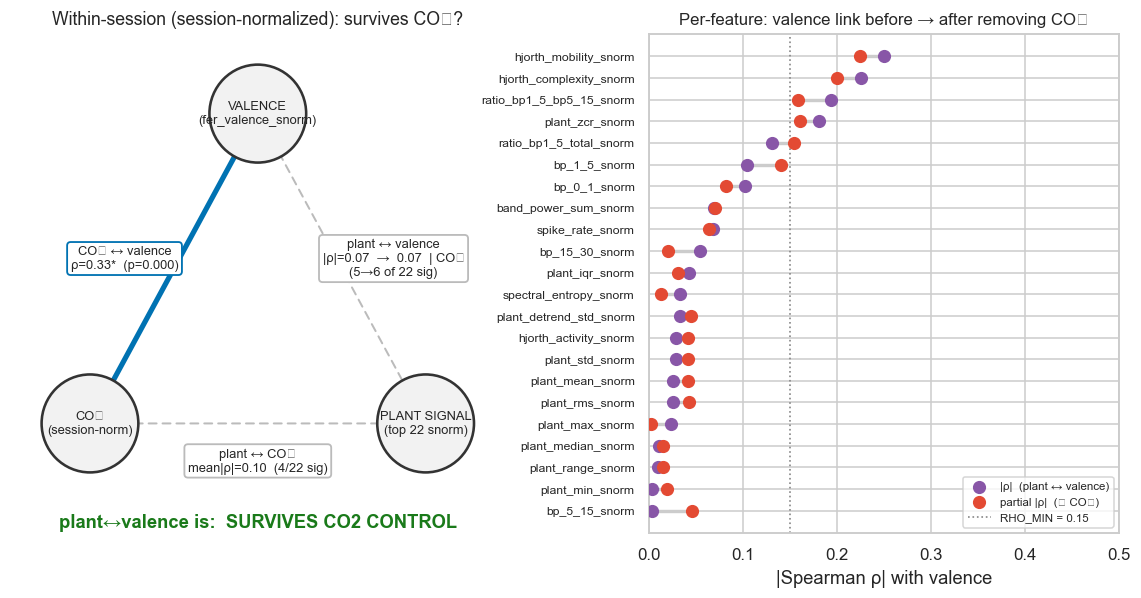

In [40]:
if CO2_COL is None:
    print("CO2 column not found - cannot draw the session-normalized triangle.")
else:
    def _es(present):
        return ("#0072B2" if present else "#BBBBBB",
                3.4 if present else 1.3, "solid" if present else (0, (4, 3)))

    fig = plt.figure(figsize=(13, 5.9))
    gs = fig.add_gridspec(1, 2, width_ratios=[1.05, 1.0], wspace=0.30)
    ax1, ax2 = fig.add_subplot(gs[0]), fig.add_subplot(gs[1])

    ax1.set_xlim(0, 10); ax1.set_ylim(0, 10); ax1.axis("off")
    P = {"VAL": (5.0, 8.4), "CO2": (1.6, 2.2), "PLANT": (8.4, 2.2)}
    node_txt = {"VAL": "VALENCE\n(fer_valence_snorm)", "CO2": "CO\u2082\n(session-norm)",
                "PLANT": f"PLANT SIGNAL\n(top {N_TOP} snorm)"}

    def draw_edge(a, b, present, label, lx, ly):
        color, lw, ls = _es(present)
        (x1, y1), (x2, y2) = P[a], P[b]
        ax1.annotate("", xy=(x2, y2), xytext=(x1, y1),
                     arrowprops=dict(arrowstyle="-", color=color, lw=lw, linestyle=ls))
        ax1.text(lx, ly, label, ha="center", va="center", fontsize=8.4,
                 bbox=dict(boxstyle="round,pad=0.28", fc="white", ec=color, lw=1.2))

    draw_edge("VAL", "PLANT", _leg_present(PV_mean_sn, PV_frac_sn),
              f"plant \u2194 valence\n|\u03c1|={PV_mean_sn:.2f}  \u2192  {PART_mean_sn:.2f}  | CO\u2082\n"
              f"({PV_sig_sn}\u2192{PART_sig_sn} of {N_TOP} sig)", 7.75, 5.5)
    draw_edge("CO2", "PLANT", legPC_present_sn,
              f"plant \u2194 CO\u2082\nmean|\u03c1|={PC_mean_sn:.2f}  ({PC_sig_sn}/{N_TOP} sig)", 5.0, 1.45)
    star = "*" if legCV_present_sn else ""
    draw_edge("CO2", "VAL", legCV_present_sn,
              f"CO\u2082 \u2194 valence\n\u03c1={co2v_rho_sn:.2f}{star}  (p={co2v_p_sn:.3f})", 2.3, 5.5)

    for k, (x, y) in P.items():
        ax1.add_patch(Circle((x, y), 0.98, fc="#F2F2F2", ec="#333333", lw=1.7, zorder=5))
        ax1.text(x, y, node_txt[k], ha="center", va="center", fontsize=8.4, zorder=6)

    vcolor = {"CONFOUNDED": "#B00020", "PARTLY CONFOUNDED": "#B8860B",
              "SURVIVES CO2 CONTROL": "#1a7a1a"}[confound_verdict_sn]
    ax1.text(5, 0.12, f"plant\u2194valence is:  {confound_verdict_sn}", ha="center",
             fontsize=12, color=vcolor, weight="bold")
    ax1.set_title("Within-session (session-normalized): survives CO\u2082?", fontsize=11.5)

    m = leg_pv_sn.copy()
    m = m.reindex(m["rho"].abs().sort_values().index).reset_index(drop=True)
    yy = np.arange(len(m))
    for i, r in m.iterrows():
        ax2.plot([abs(r["rho"]), abs(r["partial_rho"])], [i, i], color="#CCCCCC", lw=2.2, zorder=1)
    ax2.scatter(m["rho"].abs(), yy, s=58, color="#8856a7", zorder=3, label="|\u03c1|  (plant \u2194 valence)")
    ax2.scatter(m["partial_rho"].abs(), yy, s=58, color="#e34a33", zorder=3, label="partial |\u03c1|  (\u2223 CO\u2082)")
    ax2.axvline(RHO_MIN, color="#888888", ls=":", lw=1.1, label=f"RHO_MIN = {RHO_MIN}")
    ax2.set_yticks(yy); ax2.set_yticklabels(m["plant_feature"], fontsize=8)
    ax2.set_xlabel("|Spearman \u03c1| with valence"); ax2.set_xlim(0, max(0.5, m["rho"].abs().max() * 1.15))
    ax2.set_title("Per-feature: valence link before \u2192 after removing CO\u2082", fontsize=11)
    ax2.legend(fontsize=7.5, loc="lower right")
    plt.tight_layout(); plt.show()

In [41]:
if CO2_COL is None:
    display(Markdown("CO\u2082 not in dataset - session-normalized interpretation skipped."))
else:
    delta = PART_mean_sn - PV_mean_sn
    pct = 100 * delta / PV_mean_sn if PV_mean_sn > 0 else float("nan")
    if abs(pct) < 5:
        change = f"essentially unchanged (mean|\u03c1| {PV_mean_sn:.2f} \u2192 {PART_mean_sn:.2f})"
    elif delta < 0:
        change = f"reduced by ~{abs(pct):.0f}% (mean|\u03c1| {PV_mean_sn:.2f} \u2192 {PART_mean_sn:.2f})"
    else:
        change = f"slightly stronger, not weaker (mean|\u03c1| {PV_mean_sn:.2f} \u2192 {PART_mean_sn:.2f})"

    explains = {"CONFOUNDED": "Yes.", "PARTLY CONFOUNDED": "Partly.", "SURVIVES CO2 CONTROL": "No."}[confound_verdict_sn]
    head = {"CONFOUNDED": f"**Within session, CO\u2082 accounts for most of the plant\u2194valence link** ({change}).",
            "PARTLY CONFOUNDED": f"**Within session, CO\u2082 accounts for part of the plant\u2194valence link** ({change}).",
            "SURVIVES CO2 CONTROL": f"**Within session, the plant\u2194valence link is not explained by CO\u2082** ({change})."}[confound_verdict_sn]

    # how much of the raw plant<->CO2 leg was between-session?
    if PC_mean > 0 and not np.isnan(PC_mean_sn):
        drop = 100 * (1 - PC_mean_sn / PC_mean)
        between = (f"The `plant \u2194 CO\u2082` leg falls from **{PC_mean:.2f}** (raw) to **{PC_mean_sn:.2f}** "
                   f"(within-session) \u2014 about **{drop:.0f}%** of the raw coupling was between-session "
                   f"(stuffier-room / baseline offsets), not the plant responding to CO\u2082 moment-to-moment.")
    else:
        between = ""

    lines = [head, "",
        f"- **Does the plant sense CO\u2082 *within* a recording?** "
        + (f"Yes \u2014 within-session plant\u2194CO\u2082 = {PC_mean_sn:.2f} ({PC_sig_sn}/{N_TOP} sig)."
           if legPC_present_sn else
           f"Weakly \u2014 within-session plant\u2194CO\u2082 = {PC_mean_sn:.2f} ({PC_sig_sn}/{N_TOP} sig)."),
        f"- **CO\u2082 \u2194 valence (within session):** \u03c1 = {co2v_rho_sn:.2f} (p = {co2v_p_sn:.3f}).",
        f"- **Does CO\u2082 explain the within-session plant\u2194valence link?** {explains} Controlling for CO\u2082 leaves it {change}.",
        "", between, "",
        "This is the clean answer to the open-door/window worry: with every signal centred per "
        "session, the between-session differences are gone, so what remains is genuine within-session "
        "co-movement. Compare it against the raw analysis (\u00a77) using the table below.",
    ]
    display(Markdown("\n".join(lines)))

**Within session, the plant↔valence link is not explained by CO₂** (essentially unchanged (mean|ρ| 0.07 → 0.07)).

- **Does the plant sense CO₂ *within* a recording?** Weakly — within-session plant↔CO₂ = 0.10 (4/22 sig).
- **CO₂ ↔ valence (within session):** ρ = 0.33 (p = 0.000).
- **Does CO₂ explain the within-session plant↔valence link?** No. Controlling for CO₂ leaves it essentially unchanged (mean|ρ| 0.07 → 0.07).

The `plant ↔ CO₂` leg falls from **0.42** (raw) to **0.10** (within-session) — about **76%** of the raw coupling was between-session (stuffier-room / baseline offsets), not the plant responding to CO₂ moment-to-moment.

This is the clean answer to the open-door/window worry: with every signal centred per session, the between-session differences are gone, so what remains is genuine within-session co-movement. Compare it against the raw analysis (§7) using the table below.

## 9  Raw vs session-normalized — reading them together

The two analyses answer complementary questions, and the honest conclusion
comes from holding them side by side:

- **Raw (§1–7)** keeps each session's absolute baseline, so its
  `plant ↔ CO₂` (**0.40** on this dataset) is *within + between* session. That
  is where the slow CO₂ baseline-drift lives — and also where the
  open-door/window differences live.
- **Session-normalized (§8)** removes every session's baseline, so its
  `plant ↔ CO₂` is *within-session only* — the plant actually responding to
  CO₂ as it changes during a recording.

**What to look for in the table below.** If the within-session
`plant ↔ CO₂` is much smaller than the raw 0.40, then most of the raw
coupling was between-session ambient variation, and the plant's genuine
moment-to-moment sensitivity to CO₂ is weaker than the raw number suggests.
Either way, the decisive `plant ↔ valence | CO₂` line is the one that
answers your original question: in the raw analysis it **survived** CO₂
control (0.16 → 0.17); if it also survives here, the (weak) valence signal in
the plant is not a CO₂ artefact at *either* the between- or within-session
level — the strongest version of that conclusion.

In [42]:
if CO2_COL is None:
    print("CO2 not in dataset - no comparison to show.")
else:
    cmp = pd.DataFrame({
        "raw (within+between)": {
            "plant<->valence  mean|rho|":        round(PV_mean, 3),
            "plant<->valence | CO2  mean|rho|":  round(PART_mean, 3),
            "plant<->CO2 (lag)  mean|rho|":      round(PC_mean, 3),
            "CO2<->valence  rho":                round(co2_val_rho, 3),
            "triangle verdict":                  verdict,
            "confound verdict":                  confound_verdict,
        },
        "session-norm (within only)": {
            "plant<->valence  mean|rho|":        round(PV_mean_sn, 3),
            "plant<->valence | CO2  mean|rho|":  round(PART_mean_sn, 3),
            "plant<->CO2 (lag)  mean|rho|":      round(PC_mean_sn, 3),
            "CO2<->valence  rho":                round(co2v_rho_sn, 3),
            "triangle verdict":                  verdict_sn,
            "confound verdict":                  confound_verdict_sn,
        },
    })
    display(cmp)

    same = confound_verdict == confound_verdict_sn
    print("\nAutomated read:")
    if PC_mean > 0:
        print(f"- plant<->CO2 leg: {PC_mean:.2f} raw -> {PC_mean_sn:.2f} within-session "
              f"({100*(1-PC_mean_sn/PC_mean):+.0f}% change) => "
              + ("much of the raw coupling was between-session."
                 if PC_mean_sn < 0.6 * PC_mean else
                 "a real within-session component remains."))
    print(f"- plant<->valence | CO2: {'survives' if confound_verdict=='SURVIVES CO2 CONTROL' else confound_verdict.lower()} (raw), "
          f"{'survives' if confound_verdict_sn=='SURVIVES CO2 CONTROL' else confound_verdict_sn.lower()} (within-session)"
          + ("  => same conclusion at both levels." if same else "  => conclusions differ; read both."))

,raw (within+between),session-norm (within only)
plant<->valence mean|rho|,0.14,0.075
plant<->valence | CO2 mean|rho|,0.145,0.074
plant<->CO2 (lag) mean|rho|,0.42,0.101
CO2<->valence rho,0.308,0.329
triangle verdict,PLAUSIBLE,PARTIAL
confound verdict,SURVIVES CO2 CONTROL,SURVIVES CO2 CONTROL



Automated read:
- plant<->CO2 leg: 0.42 raw -> 0.10 within-session (+76% change) => much of the raw coupling was between-session.
- plant<->valence | CO2: survives (raw), survives (within-session)  => same conclusion at both levels.


---

*This notebook answers one confound question — whether ambient CO₂ can
account for the plant↔valence signal that `04_03_ml_pipeline_valence.ipynb`
detects. It ranks the plant features (all of them; mirroring
`04_03` §14), tests the CO₂ triangle, and settles it with a partial
Spearman correlation `ρ(plant, valence | CO₂)`. Provenance was verified
against `02_emotion_labelling.ipynb`: `fer_valence` is computed from the
face (HSEmotion, §4.6) and thresholded into `valence_direction` (§4.8);
the plant features come from the plant voltage channel (§4.10); CO₂ is an
independently-streamed sensor (§4.6b) — so every edge here relates signals
that are not derived from one another.*